In [190]:
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np

## LIBRARY

#### Kode tersebut merupakan kode untuk mengimport library yang dibutuhkan, seperti OpenCV, Matplotlib.pyplot, dan NumPy:
- Library OpenCV digunakan untuk melakukan berbagai operasi citra seperti membaca, menampilkan, memproses, dan memodifikasi, namun pada jurnal kali ini hanya digunakan untuk membaca dan mengubah citra menjadi grayscale.
- NumPy digunakan untuk representasi citra dalam bentuk matriks array, dan pada jurnal kali ini digunakan untuk melalukan operasi pada matriks dan manipulasi piksel.
- Matplotlib digunakan untuk menampilkan citra hasil pemrosesan berbagai tahap proses

In [191]:
prewittX = np.array([
[-1, 0, 1],
[-1, 0, 1],
[-1, 0, 1]
], dtype=np.float32)
prewittY = np.array([
[1, 1, 1],
[0, 0, 0],
[-1, -1, -1]
], dtype=np.float32)
sobelX = np.array([
 [-1, 0, 1],
 [-2, 0, 2],
 [-1, 0, 1]
], dtype=np.float32)
sobelY = np.array([
 [1, 2, 1],
 [0, 0, 0],
 [-1, -2, -1]
], dtype=np.float32)

def convolution(img, kernel):
    size = kernel.shape[0]
    pad_size = size // 2
    padded = np.pad(img, pad_size, mode='constant')
    canvas = np.zeros_like(img).astype(np.float32)
    height, width = img.shape
    for i in range(height):
        for j in range(width):
            region = padded[i:i+size, j:j+size]
            canvas[i, j] = np.sum(region * kernel)
    return canvas
def edge(img, kernelx, kernely):
    gx = convolution(img, kernelx)
    gy = convolution(img, kernely)
    canvas = np.abs(gx) + np.abs(gy)
    canvas = canvas * 255.0 / np.max(canvas)
    return np.clip(canvas, 0, 255).astype(np.uint8)
def threshold(image, value, min_val, max_val):
    img = np.array(image)
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if img[i, j] > value:
                img[i, j] = max_val
            else:
                img[i, j] = min_val 
    return img
def resize(image, new_width, new_height): 
    old_height, old_width = image.shape[:2] 
    resized_image = np.zeros((new_height, new_width), dtype=np.uint8) 
    for i in range(new_height): 
        for j in range(new_width): 
            x = int(j * old_width / new_width) 
            y = int(i * old_height / new_height) 
            resized_image[i, j] = image[y, x] 
    return resized_image 

## Deklarasi Kernel dan Fungsi-Fungsi

kode di atas adalah deklarasi kernel untuk deteksi tepi dan filtering, seperti sobel dan prewitt, kemudian juga ada deklarasi fungsi-fungsi seperti konvolusi, deteksi tepi, threshold, dan resize.

Fungsi konvolusi diperlukan untuk melakukan fungsi deteksi tepi, yang di mana fungsi ini menggeser kernel (filter) di setiap piksel gambar, mengalikan nilai piksel dengan bobot kernel, lalu menjumlahkan hasilnya untuk menghasilkan nilai baru pada piksel tersebut. Fungsi deteksi tepi kemudian menggunakan dua kernel (gx, gy) untuk menghitung gradien intensitas pada kedua arah, lalu menggabungkan keduanya dengan menjumlahkan nilai absolutnya sehingga tepi pada gambar dapat terdeteksi secara menyeluruh, kemudian hasil akhirnya di normalisasi.

Kemudian, ada juga fungsi threshold dan resize, fungsi threshold digunakan untuk melakukan thresholding dengan cara mengubah nilai piksel menjadi nilai maksimum (max_val) ketika lebih dari nilai thresholdnya (value), dan ketika kurang dari nilai thresholdnya akan diubah menjadi nilai minimum (min_val). Sedangkan fungsi resize digunakan untuk mengubah ukuran (resolusi) citra ke dimensi yang diinginkan, fungsi ini bekerja dengan cara mengambil nilai dari koordinat tetangganya di citra asli, kemudian untuk setiap piksel di citra baru dihitung posisi asalnya berdasarkan skala perbandingan antara ukuran asli dan ukuran target yang kemudian dipetakan di citra baru.

Text(0.5, 1.0, 'Threshold')

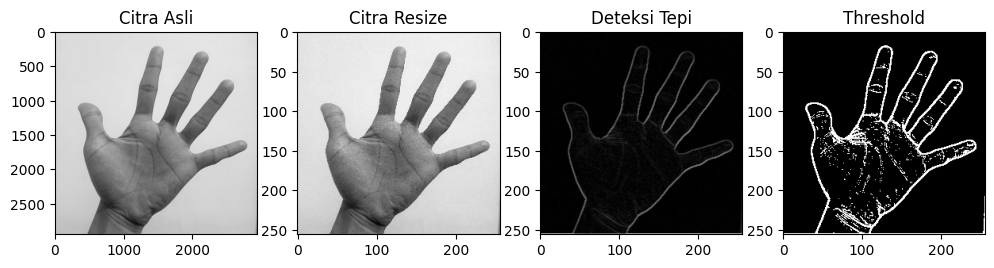

In [192]:
telapak = cv.imread('assets/telapak.jpg')
telapakG = cv.cvtColor(telapak, cv.COLOR_BGR2GRAY)
telapakR = resize(telapakG, 256, 256)
telapakDT = edge(telapakR, prewittX, prewittY)
telapakT = threshold(telapakDT, 15, 0, 255)

plt.figure(figsize = (12, 8))

plt.subplot(1, 4, 1)
plt.imshow(telapakG, cmap = 'gray')
plt.title('Citra Asli')

plt.subplot(1, 4, 2)
plt.imshow(telapakR, cmap = 'gray')
plt.title('Citra Resize')

plt.subplot(1, 4, 3)
plt.imshow(telapakDT, cmap = 'gray')
plt.title('Deteksi Tepi')

plt.subplot(1, 4, 4)
plt.imshow(telapakT, cmap = 'gray')
plt.title('Threshold')

## Membaca Gambar dan Pre-processing Citra kemudian Menampilkannya

Kode di atas digunakan untuk membaca citra dan melakukan pre-processing citra (Resize, Deteksi Tepi, Thresholding). Membaca telapak.jpg dengan menggunakan cv.imread kemmudian menyimpannya di dalam variabel telapak. Variabel telapak kemudian diubah menjadi citra grayscale dengan menggunakan cv.cvtColor(, cv.COLOR_BGR2GRAY) dan menyimpannya dalam variabel telapakG. Variabel telapakG kemudian di resize dengan menggunakan fungsi resize() dan disimpan dalam variabel telapakR. Variabel telapakR kemudian dideteksi tepinya dengan menggunakan fungsi edge() dan disimpan di dalam variabel telapakDT. Kemudian terakhir variabel telapakDT dithresholding dengan menggunakan fungsi threshold() dan menyimpannya dalam variabel telapakT.

Kode tersebut kemudian menampilkan variabel-variabel hasil tahapan-tahapan tadi(grayscale, resize, deteksi tepi, threshold) dalam subplot (1, 4) dengan canvass figsize=(12, 8)

In [193]:
kernel3f1 = np.array([
    [1, 1, 1],
    [1, 1, 1],
    [1, 1, 1]
])

kernel5f1 = np.array([ 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1], 
    [1,1,1,1,1] 
]) 

## Deklarasi kernel 3x3 dan 5x5

Kode di atas mendeklarasikan kernel 3x3 dan 5x5 yang disimpan di dalam variabel kernel3f1 dan kernel5f1, yang di mana keseluruhan elemen dari kernel-kernel tersebut bernilai 1.

In [194]:
def dilasi(image,kernel): 
    height, width = image.shape 
    k_height, k_width = kernel.shape 
    center = k_height // 2 
    hasil = np.zeros((height, width)) 
    for i in range(center, height-center): 
        for j in range(center, width-center): 
            if image[i,j] == 255: 
                for k in range(k_height): 
                    for l in range(k_width): 
                        if kernel[k,l] == 1: 
                            hasil[i+k-center,j+l-center] =255 
            else: 
                if hasil[i,j] !=255: 
                    hasil[i,j] = 0  
    return hasil 

def erosi(image, kernel): 
    height, width = image.shape
    k_height, k_width = kernel.shape
    center = k_height // 2
    hasil = np.zeros((height, width))
    for i in range(center, height - center):
        for j in range(center, width - center):
            cocok = True
            for k in range(k_height): 
                for l in range(k_width): 
                    if kernel[k, l] == 1 and image[i + k - center, j + l - center] == 0: 
                        cocok = False 
                        break 
                if not cocok: 
                    break 
            if cocok: 
                hasil[i, j] = 255 
    return hasil

def opening(image_erosi, kernel):
    hasil = dilasi(image_erosi, kernel)
    return hasil

def closing(image_dilasi, kernel):
    hasil = erosi(image_dilasi, kernel)
    return hasil

def thinning(img): 
    binary = (img > 0).astype(np.uint8) 
    height, width = binary.shape 
    changed = True 
    while changed: 
        changed = False 
        hapus = [] 
        # STEP 1 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P6 == 0 and 
                    P4 * P6 * P8 == 0 
                ):
                     hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
        hapus = [] 
        # STEP 2 
        for i in range(1, height-1): 
            for j in range(1, width-1): 
 
                P1 = binary[i, j] 
                if P1 != 1: 
                    continue 
                P2 = binary[i-1, j] 
                P3 = binary[i-1, j+1] 
                P4 = binary[i, j+1] 
                P5 = binary[i+1, j+1] 
                P6 = binary[i+1, j] 
                P7 = binary[i+1, j-1] 
                P8 = binary[i, j-1] 
                P9 = binary[i-1, j-1] 
                tetangga = [P2,P3,P4,P5,P6,P7,P8,P9] 
                jumlah = np.sum(tetangga) 
                transisi = 0 
                urutan = tetangga + [P2] 
                for k in range(8): 
                    if urutan[k] == 0 and urutan[k+1] == 1: 
                        transisi += 1 
 
                if ( 
                    2 <= jumlah <= 6 and 
                    transisi == 1 and 
                    P2 * P4 * P8 == 0 and 
                    P2 * P6 * P8 == 0 
                ): 
                    hapus.append((i,j)) 
        if hapus: 
            changed = True 
            for i,j in hapus: 
                binary[i,j] = 0 
    return binary * 255

def thickening(img, kernel, iterasi=1): 
    hasil = img.copy() 
    for _ in range(iterasi): 
        hasil = dilasi(hasil, kernel) 
    return hasil

def gradientMorph(erosi, dilasi):
    hasil = dilasi - erosi
    return hasil

## Deklarasi Fungsi-Fungsi Morfologi Citra

Kode di atas adalah deklarasi fungsi-fungsi morfologi citra, seperti dilasi, erosi, opening, closing, thinning, thickening, dan gradient morfologi.

Fungsi dilasi bekerja dengan cara memeriksa setiap piksel putih (255) pada citra, kemudian menyebarkan nilai putih tersebut ke piksel-piksel tetangganya sesuai dengan bentuk kernel yang digunakan. Sebaliknya, fungsi erosi bekerja dengan cara memeriksa apakah seluruh piksel di bawah kernel bernilai putih, jika iya maka piksel pusat dipertahankan sebagai putih, jika tidak maka piksel tersebut dihapus menjadi nol.

Fungsi opening merupakan kombinasi erosi yang dilanjutkan dengan dilasi, yang digunakan untuk menghilangkan noise kecil pada citra biner. Sedangkan fungsi closing merupakan kebalikannya, yaitu dilasi yang dilanjutkan dengan erosi, yang digunakan untuk menutup celah kecil pada objek di citra biner.

Kemudian, ada juga fungsi thinning yang mengimplementasikan algoritma Zhang-Suen, di mana fungsi ini mengikis piksel-piksel tepi objek secara iteratif dalam dua langkah hingga tidak ada lagi perubahan, sehingga menghasilkan representasi objek yang hanya selebar satu piksel (kerangka). Fungsi thickening bekerja sebaliknya, yaitu menebalkan objek pada citra dengan cara menerapkan dilasi sebanyak jumlah iterasi yang ditentukan. Terakhir, fungsi gradientMorph menghitung gradien morfologi dengan cara mengurangkan hasil erosi dari hasil dilasi, sehingga menghasilkan citra yang menonjolkan kontur atau tepi dari objek.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

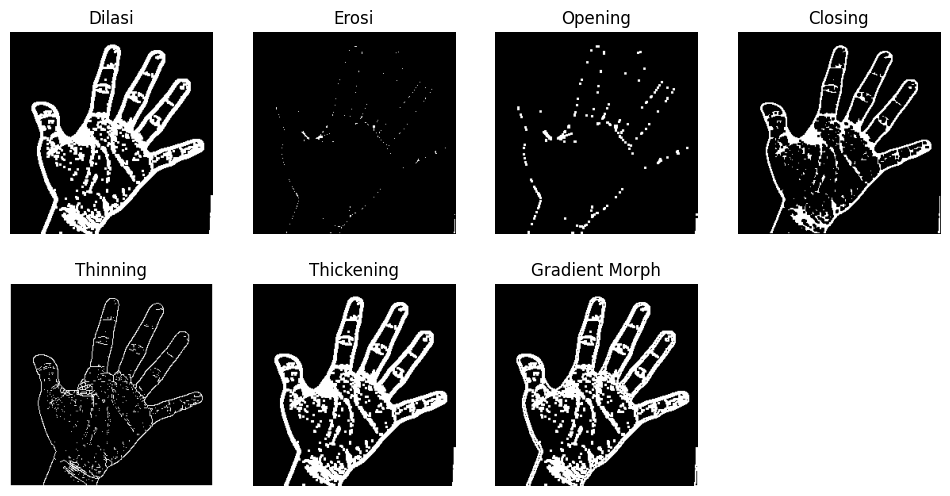

In [204]:
telapakDilasi = dilasi(telapakT, kernel3f1)
telapakErosi = erosi(telapakT, kernel3f1)
telapakOpening = opening(telapakErosi, kernel3f1)
telapakClosing = closing(telapakDilasi, kernel3f1)
telapakThinning = thinning(telapakT)
telapakThickening = thickening(telapakT, kernel3f1)
telapakGM = gradientMorph(telapakErosi, telapakDilasi)

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(telapakDilasi, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(telapakErosi, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(telapakOpening, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(telapakClosing, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(telapakThinning, cmap = 'gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(telapakThickening, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(telapakGM, cmap = 'gray')
plt.title('Gradient Morph')
plt.axis('off')

## Operasi Morfologi Kernel 3x3 dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi-operasi morfologi pada citra telapak biner (telapakT) menggunakan kernel3f1. Variabel telapakT dilakukan operasi dilasi dan hasilnya disimpan dalam variabel telapakDilasi. Variabel telapakT juga dilakukan operasi erosi dan hasilnya disimpan dalam variabel telapakErosi. Variabel telapakErosi kemudian dilakukan operasi opening dan disimpan dalam variabel telapakOpening, sedangkan variabel telapakDilasi dilakukan operasi closing dan disimpan dalam variabel telapakClosing. Variabel telapakT juga dilakukan operasi thinning dan thickening yang masing-masing disimpan dalam variabel telapakThinning dan telapakThickening. Terakhir, variabel telapakErosi dan telapakDilasi digunakan untuk menghitung gradient morfologi yang disimpan dalam variabel telapakGM.

Kode tersebut kemudian menampilkan seluruh hasil operasi morfologi tadi (dilasi, erosi, opening, closing, thinning, thickening, gradient morph) dalam subplot (2, 4) dengan canvas figsize=(12, 6).

## Analisis Hasil Operasi Morfologi dengan kernel3f1

Berikut adalah analisis perbandingan citra telapak tangan sebelum dan sesudah dilakukan operasi morfologi menggunakan kernel3f1.

**Dilasi** — Setelah dilasi, piksel-piksel putih pada citra melebar ke arah tetangganya sehingga putih-putih pada telapak tangan terlihat lebih tebal dan besar dibanding citra aslinya. Celah-celah kecil antar piksel putih juga ikut tertutup akibat penyebaran nilai putih oleh kernel.

**Erosi** — Setelah erosi, objek telapak tangan mengalami pengikisan pada bagian tepinya sehingga hanya piksel-piksel yang benar-benar dikelilingi oleh piksel putih saja yang tersisa. Hasilnya, telapak tangan terlihat jauh lebih tipis dan banyak bagian yang hilang, terutama pada area yang memiliki noise atau piksel putih yang tersebar.

**Opening** — Opening yang merupakan erosi dilanjutkan dilasi menghasilkan citra yang noise-noise kecilnya sebagian besar sudah hilang. Namun bentuk telapak tangan tidak terlalu berubah signifikan dibanding hasil erosi, hanya saja piksel-piksel yang tersisa sedikit melebar kembali.

**Closing** — Closing yang merupakan dilasi dilanjutkan erosi menghasilkan citra di mana celah-celah kecil pada objek telapak tangan berhasil tertutup. Bentuk objek secara keseluruhan lebih rapat dan utuh dibanding citra asli, dengan kontur yang lebih halus.

**Thinning** — Setelah thinning, objek telapak tangan tereduksi menjadi representasi kerangka yang hanya selebar satu piksel. Bentuk umum telapak dan jari masih dapat dikenali, namun semua area yang sebelumnya berupa bidang penuh kini menjadi garis tipis yang mengikuti struktur objek.

**Thickening** — Setelah thickening, objek telapak tangan mengalami penebalan yang lebih agresif dibanding dilasi biasa. Objek terlihat lebih besar dan masif, dengan banyak celah yang tertutup serta kontur luar yang semakin melebar menjauhi bentuk aslinya.

**Gradient Morphology** — Gradient morfologi yang diperoleh dari selisih dilasi dan erosi menghasilkan citra yang hanya menonjolkan bagian tepi atau kontur dari objek telapak tangan. Hasilnya menyerupai hasil deteksi tepi, di mana bagian dalam objek tampak hitam dan hanya batas-batas tepinya saja yang berwarna putih.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

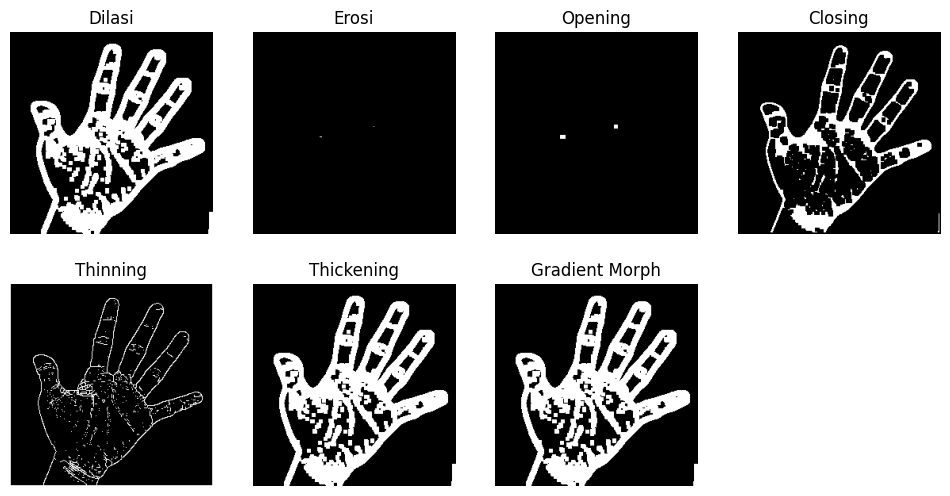

In [205]:
telapakDilasi2 = dilasi(telapakT, kernel5f1)
telapakErosi2 = erosi(telapakT, kernel5f1)
telapakOpening2 = opening(telapakErosi2, kernel5f1)
telapakClosing2 = closing(telapakDilasi2, kernel5f1)
telapakThinning2 = thinning(telapakT)
telapakThickening2 = thickening(telapakT, kernel5f1)
telapakGM2 = gradientMorph(telapakErosi2, telapakDilasi2)

plt.figure(figsize=(12, 6))

plt.subplot(2, 4, 1)
plt.imshow(telapakDilasi2, cmap = 'gray')
plt.title('Dilasi')
plt.axis('off')

plt.subplot(2, 4, 2)
plt.imshow(telapakErosi2, cmap = 'gray')
plt.title('Erosi')
plt.axis('off')

plt.subplot(2, 4, 3)
plt.imshow(telapakOpening2, cmap = 'gray')
plt.title('Opening')
plt.axis('off')

plt.subplot(2, 4, 4)
plt.imshow(telapakClosing2, cmap = 'gray')
plt.title('Closing')
plt.axis('off')

plt.subplot(2, 4, 5)
plt.imshow(telapakThinning2, cmap = 'gray')
plt.title('Thinning')
plt.axis('off')

plt.subplot(2, 4, 6)
plt.imshow(telapakThickening2, cmap = 'gray')
plt.title('Thickening')
plt.axis('off')

plt.subplot(2, 4, 7)
plt.imshow(telapakGM2, cmap = 'gray')
plt.title('Gradient Morph')
plt.axis('off')

## Operasi Morfologi Kernel 5x5 dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi-operasi morfologi pada citra telapak biner (telapakT) menggunakan kernel5f1. Variabel telapakT dilakukan operasi dilasi dan hasilnya disimpan dalam variabel telapakDilasi2. Variabel telapakT juga dilakukan operasi erosi dan hasilnya disimpan dalam variabel telapakErosi2. Variabel telapakErosi2 kemudian dilakukan operasi opening dan disimpan dalam variabel telapakOpening2, sedangkan variabel telapakDilasi2 dilakukan operasi closing dan disimpan dalam variabel telapakClosing2. Variabel telapakT juga dilakukan operasi thinning dan thickening yang masing-masing disimpan dalam variabel telapakThinning2 dan telapakThickening2. Terakhir, variabel telapakErosi2 dan telapakDilasi2 digunakan untuk menghitung gradient morfologi yang disimpan dalam variabel telapakGM2.

Kode tersebut kemudian menampilkan seluruh hasil operasi morfologi tadi (dilasi, erosi, opening, closing, thinning, thickening, gradient morph) dalam subplot (2, 4) dengan canvas figsize=(12, 6).

## Analisis Perbandingan Hasil Operasi Morfologi kernel3f1 vs kernel5f1

Berikut adalah analisis perbandingan hasil operasi morfologi pada citra telapak tangan menggunakan kernel3f1 (kernel 3×3) dan kernel5f1 (kernel 5×5).

**Dilasi** — Hasil dilasi pada kedua kernel terlihat serupa dalam hal pelebaran objek, namun pada kernel5f1 pelebaran piksel putih terlihat lebih agresif karena jangkauan kernelnya yang lebih besar. Celah-celah kecil pada objek telapak tangan lebih banyak tertutup pada kernel5f1 dibanding kernel3f1.

**Erosi** — Perbedaan paling mencolok terlihat pada hasil erosi. Kernel3f1 masih menyisakan struktur telapak tangan yang cukup terlihat meski sudah terkikis, sedangkan kernel5f1 menghasilkan erosi yang jauh lebih ekstrem hingga hampir seluruh piksel putih hilang dan hanya tersisa sangat sedikit piksel yang benar-benar dikelilingi penuh oleh piksel putih.

**Opening** — Sejalan dengan hasil erosi, opening pada kernel5f1 menghasilkan citra yang hampir kosong dengan hanya beberapa titik piksel putih yang tersisa, sedangkan kernel3f1 masih memperlihatkan pola struktur telapak tangan meski sudah bersih dari sebagian besar noise.

**Closing** — Hasil closing pada kedua kernel sama-sama menghasilkan objek yang lebih rapat dan utuh, namun kernel5f1 menghasilkan closing yang lebih agresif sehingga lebih banyak celah yang tertutup dan kontur objek terlihat lebih halus dan masif dibanding kernel3f1.

**Thinning** — Hasil thinning pada kedua kernel relatif serupa karena operasi thinning tidak bergantung pada kernel melainkan menggunakan algoritma Zhang-Suen yang tetap, sehingga kerangka (skeleton) yang dihasilkan keduanya memiliki bentuk yang hampir identik.

**Thickening** — Kernel5f1 menghasilkan thickening yang lebih tebal dan melebar dibanding kernel3f1, karena setiap iterasi dilasi yang dilakukan kernel5f1 menyebarkan piksel putih lebih jauh ke tetangganya. Objek telapak tangan pada kernel5f1 terlihat lebih besar dan lebih banyak celah yang tertutup.

**Gradient Morphology** — Karena selisih antara dilasi dan erosi pada kernel5f1 lebih besar (erosi lebih ekstrem, dilasi lebih lebar), gradient morfologi yang dihasilkan kernel5f1 menampilkan tepi yang lebih tebal dibanding kernel3f1. Kernel3f1 menghasilkan tepi yang lebih tipis dan detail, sedangkan kernel5f1 menghasilkan tepi yang lebih lebar dan menonjol.

Secara keseluruhan, semakin besar ukuran kernel maka semakin agresif efek yang dihasilkan pada setiap operasi morfologi, yang di mana hal ini paling terlihat jelas pada operasi erosi dan opening yang hasilnya sangat berbeda antara kernel3f1 dan kernel5f1.

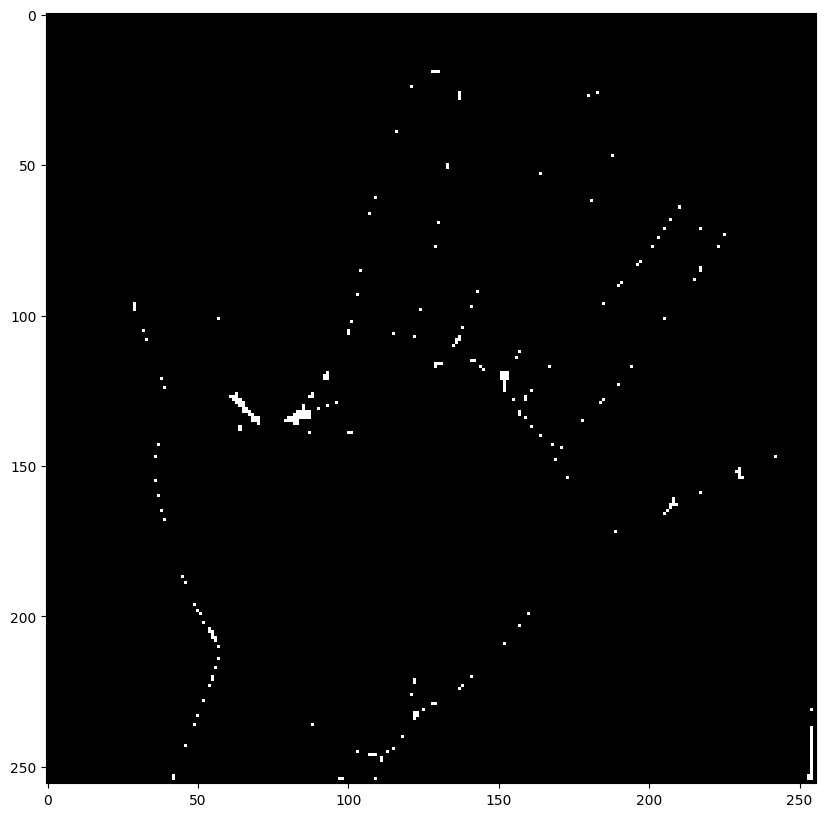

In [197]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakO = opening(telapakE, kernel3f1)
telapakOC = closing(telapakO, kernel3f1)

plt.figure(figsize = (10, 10))
plt.imshow(telapakOC, cmap = 'gray')

## Opening-Closing dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi opening-closing secara berurutan pada citra telapak biner (telapakT) menggunakan kernel3f1. Pertama, variabel telapakT dilakukan operasi dilasi dan erosi yang hasilnya masing-masing disimpan dalam variabel telapakD dan telapakE. Variabel telapakE kemudian dilakukan operasi opening dan disimpan dalam variabel telapakO, lalu variabel telapakO dilakukan operasi closing dan hasilnya disimpan dalam variabel telapakOC.

Kode tersebut kemudian menampilkan hasil akhir operasi opening-closing (telapakOC) dalam satu canvas tunggal dengan figsize=(10, 10).

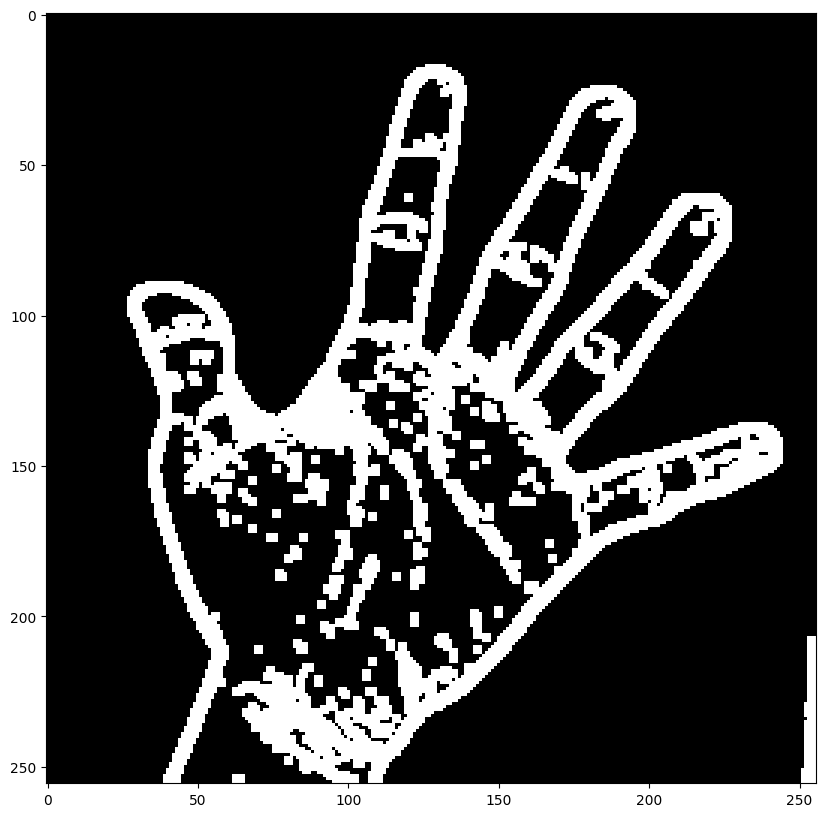

In [198]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakC = closing(telapakD, kernel3f1)
telapakCO = opening(telapakC, kernel3f1)

plt.figure(figsize = (10, 10))
plt.imshow(telapakCO, cmap = 'gray')

## Closing-Opening dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi closing-opening secara berurutan pada citra telapak biner (telapakT) menggunakan kernel3f1. Pertama, variabel telapakT dilakukan operasi dilasi dan erosi yang hasilnya masing-masing disimpan dalam variabel telapakD dan telapakE. Variabel telapakD kemudian dilakukan operasi closing dan disimpan dalam variabel telapakC, lalu variabel telapakC dilakukan operasi opening dan hasilnya disimpan dalam variabel telapakCO.

Kode tersebut kemudian menampilkan hasil akhir operasi closing-opening (telapakCO) dalam satu canvas tunggal dengan figsize=(10, 10).

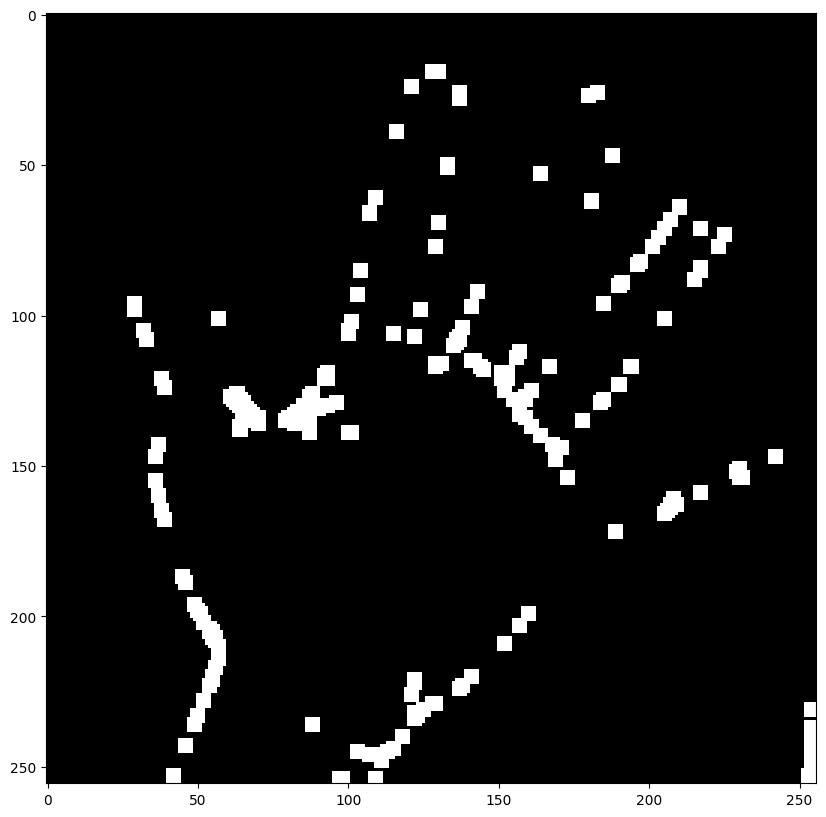

In [199]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakO = opening(telapakE, kernel3f1)
telapakOD = dilasi(telapakO, kernel3f1)

plt.figure(figsize = (10, 10))
plt.imshow(telapakOD, cmap = 'gray')

## Opening-Dilasi dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi opening-dilasi secara berurutan pada citra telapak biner (telapakT) menggunakan kernel3f1. Pertama, variabel telapakT dilakukan operasi dilasi dan erosi yang hasilnya masing-masing disimpan dalam variabel telapakD dan telapakE. Variabel telapakE kemudian dilakukan operasi opening dan disimpan dalam variabel telapakO, lalu variabel telapakO dilakukan operasi dilasi kembali dan hasilnya disimpan dalam variabel telapakOD.

Kode tersebut kemudian menampilkan hasil akhir operasi opening-dilasi (telapakOD) dalam satu canvas tunggal dengan figsize=(10, 10).

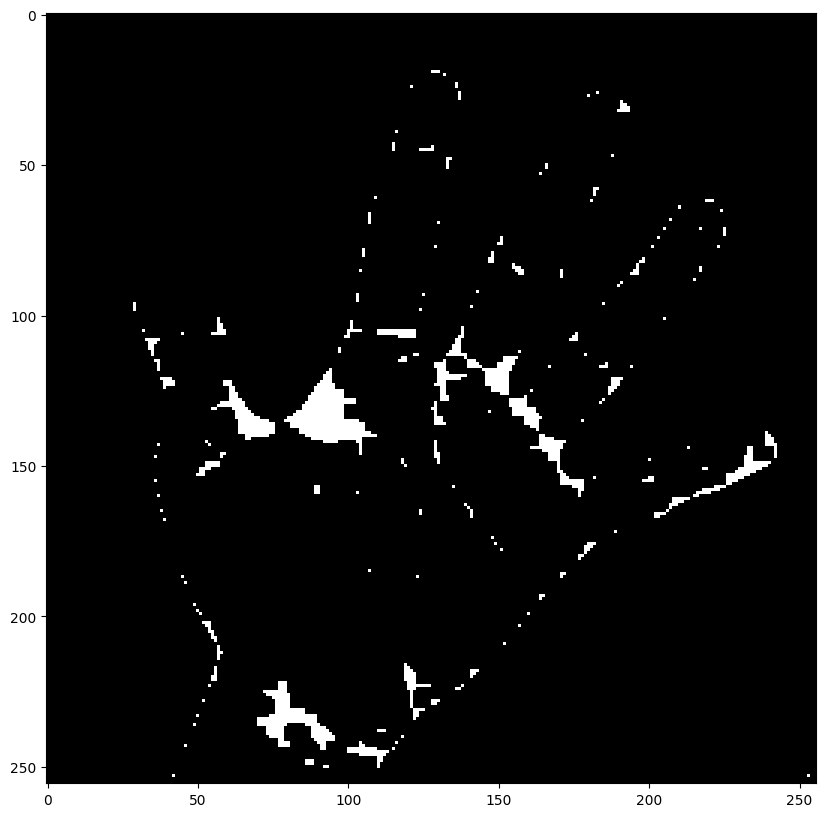

In [200]:
telapakD = dilasi(telapakT, kernel3f1)
telapakE = erosi(telapakT, kernel3f1)
telapakC = closing(telapakD, kernel3f1)
telapakCE = erosi(telapakC, kernel3f1)

plt.figure(figsize = (10, 10))
plt.imshow(telapakCE, cmap = 'gray')

## Closing-Erosi dan Menampilkannya

Kode di atas digunakan untuk melakukan operasi closing-erosi secara berurutan pada citra telapak biner (telapakT) menggunakan kernel3f1. Pertama, variabel telapakT dilakukan operasi dilasi dan erosi yang hasilnya masing-masing disimpan dalam variabel telapakD dan telapakE. Variabel telapakD kemudian dilakukan operasi closing dan disimpan dalam variabel telapakC, lalu variabel telapakC dilakukan operasi erosi kembali dan hasilnya disimpan dalam variabel telapakCE.

Kode tersebut kemudian menampilkan hasil akhir operasi closing-erosi (telapakCE) dalam satu canvas tunggal dengan figsize=(10, 10).

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

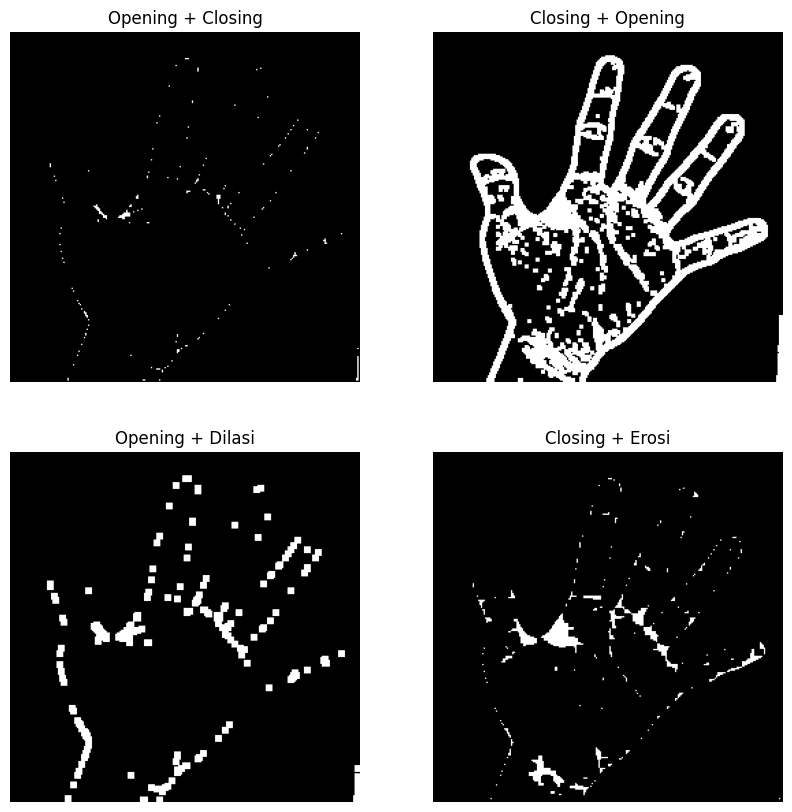

In [201]:
plt.figure(figsize = (10, 10))

plt.subplot(2, 2, 1)
plt.imshow(telapakOC, cmap = 'gray')
plt.title('Opening + Closing')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(telapakCO, cmap = 'gray')
plt.title('Closing + Opening')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(telapakOD, cmap = 'gray')
plt.title('Opening + Dilasi')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(telapakCE, cmap = 'gray')
plt.title('Closing + Erosi')
plt.axis('off')

## Analisis Hasil Kombinasi Operasi Morfologi

Berikut adalah analisis perbandingan hasil kombinasi operasi morfologi terhadap citra asli (telapakT) dan hasil operasi morfologi tunggal.

**Opening + Closing** — Kombinasi ini menghasilkan citra yang sangat bersih dari noise namun objek telapak tangan hampir tidak terlihat, hanya menyisakan titik-titik dan garis samar yang mengikuti struktur telapak. Dibanding operasi opening tunggal yang sudah cukup menghilangkan noise, penambahan closing setelahnya tidak cukup mampu mengembalikan bentuk objek secara signifikan karena piksel yang tersisa setelah opening sudah terlalu sedikit. Batas objek menjadi sangat tidak jelas dan ketebalan objek jauh berkurang dibanding citra asli.

**Closing + Opening** — Kombinasi ini menghasilkan citra yang paling mendekati bentuk objek asli dibanding ketiga kombinasi lainnya, dengan kontur telapak tangan yang jelas dan tegas. Closing terlebih dahulu menutup celah-celah pada objek sehingga bentuk telapak menjadi lebih utuh dan masif, kemudian opening membersihkan noise-noise kecil di luar objek sehingga batas objek menjadi lebih bersih dan tajam. Ketebalan objek juga relatif terjaga dengan baik dibanding citra asli.

**Opening + Dilasi** — Kombinasi ini menghasilkan citra dengan piksel-piksel putih yang tersebar dalam bentuk blok-blok kecil yang tidak berkesinambungan. Opening terlebih dahulu mengikis dan membersihkan sebagian besar piksel, kemudian dilasi melebarkan sisa piksel tersebut sehingga menghasilkan gumpalan-gumpalan kecil yang tersebar mengikuti pola struktur telapak. Dibanding dilasi tunggal yang menghasilkan objek tebal dan utuh, kombinasi ini justru menghasilkan objek yang terfragmentasi dengan batas yang tidak jelas.

**Closing + Erosi** — Kombinasi ini menghasilkan citra yang menampilkan kontur dan detail internal telapak tangan dengan cukup baik. Closing terlebih dahulu memperkuat dan merapatkan objek, namun erosi setelahnya mengikis kembali bagian tepi objek sehingga yang tersisa adalah bagian-bagian inti objek beserta detail tekstur telapak. Dibanding erosi tunggal yang hampir menghilangkan seluruh objek, kombinasi ini menghasilkan citra yang lebih kaya informasi karena closing sebelumnya sudah memperkuat piksel-piksel objek terlebih dahulu.

Secara keseluruhan, urutan operasi dalam kombinasi morfologi sangat berpengaruh terhadap hasil akhir citra. Kombinasi Closing + Opening terbukti paling efektif dalam mempertahankan bentuk objek sekaligus membersihkan noise, sedangkan kombinasi Opening + Closing justru terlalu agresif dalam menghilangkan piksel sehingga informasi objek banyak yang hilang.

In [202]:
def filter(img, size, mode):
    height, width = img.shape
    pad = size // 2
    padded = np.pad(img, pad, mode='edge')
    canvas = np.zeros_like(img, dtype=np.uint8)
    
    match mode:
        case 'mean':
            area = size * size
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    total = 0
                    for val in region.ravel():
                        total += val
                    canvas[i, j] = total // area
        case 'median':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel().tolist()
                    values.sort()
                    n = len(values)
                    mid = n // 2
                    if n % 2 == 1:
                        median_val = values[mid]
                    else:
                        median_val = (values[mid - 1] + values[mid]) // 2
                    canvas[i, j] = median_val
        case 'modus':
            for i in range(height):
                for j in range(width):
                    region = padded[i:i+size, j:j+size]
                    values = region.ravel()
                    count = {}
                    for val in values:
                        if val in count:
                            count[val] += 1
                        else:
                            count[val] = 1
                    max_count = 0
                    mode_val = 0
                    for val, freq in count.items():
                        if freq > max_count:
                            max_count = freq
                            mode_val = val
                    canvas[i, j] = mode_val
    return canvas

Text(0.5, 1.0, 'Hasil Akhir (Deteksi Tepi (Sobel))')

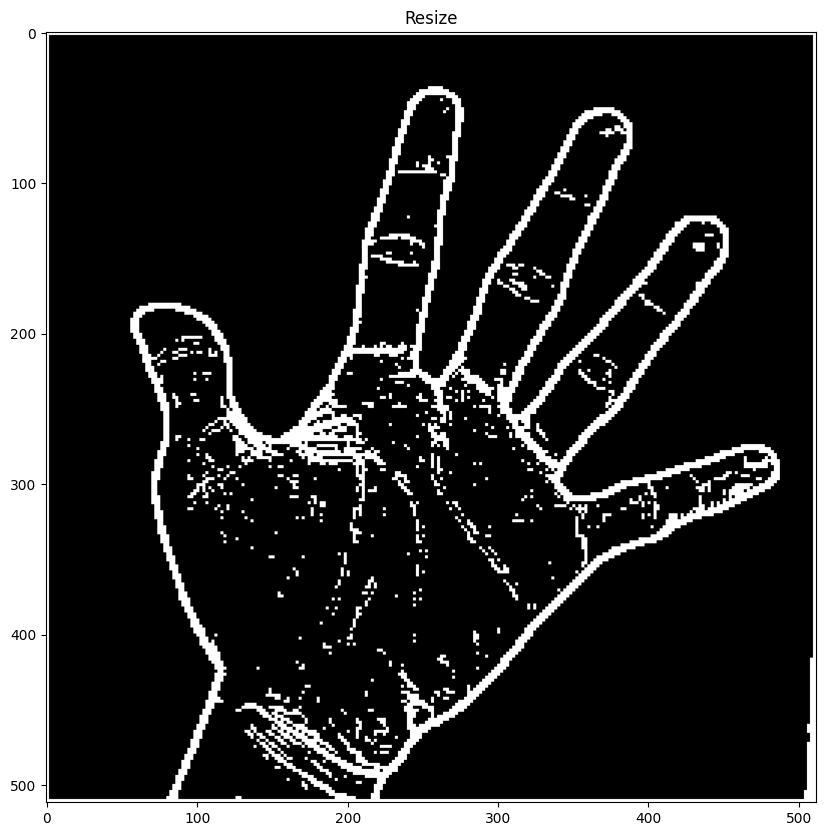

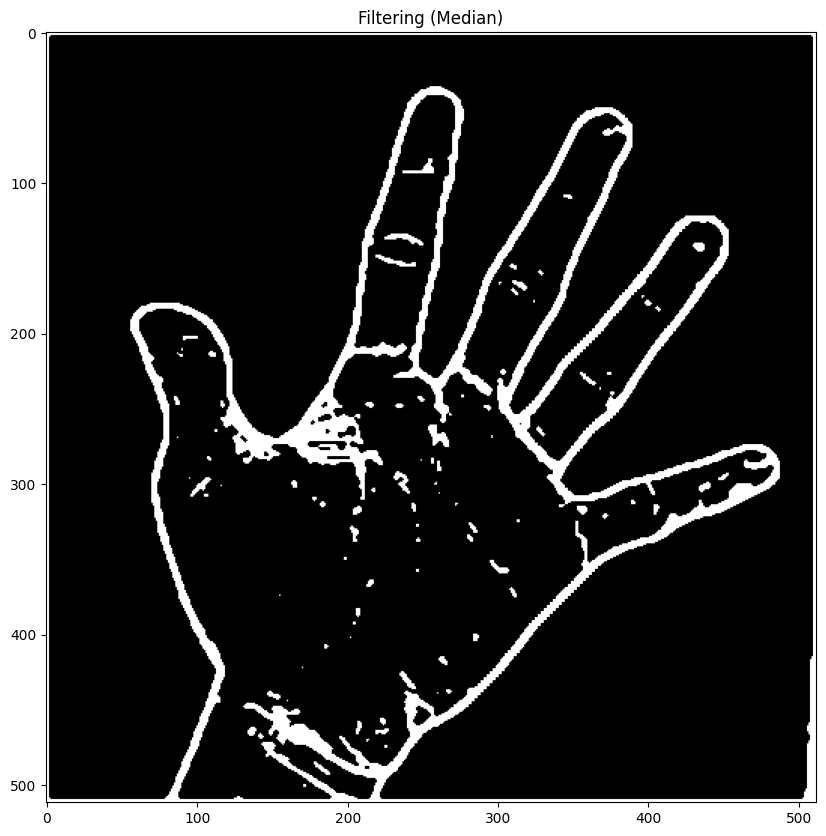

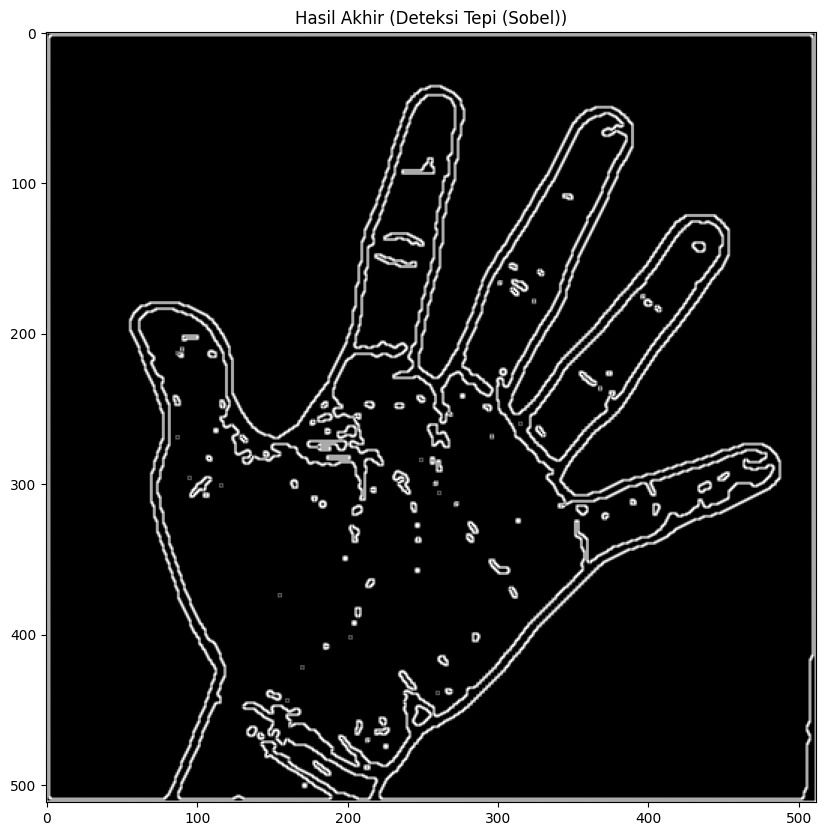

In [214]:
telapakR = resize(telapakT, 512, 512)
plt.figure(figsize = (10, 10))
plt.imshow(telapakR, cmap = 'gray')
plt.title('Resize')

telapakM = filter(telapakR, 3, 'median')
telapakM = filter(telapakM, 3, 'median')
telapakM = filter(telapakM, 3, 'median')
plt.figure(figsize = (10, 10))
plt.imshow(telapakM, cmap = 'gray')
plt.title('Filtering (Median)')

telapakDT = edge(telapakM, sobelX, sobelY)
plt.figure(figsize = (10, 10))
plt.imshow(telapakDT, cmap = 'gray')
plt.title('Hasil Akhir (Deteksi Tepi (Sobel))')

## Eksplorasi Pengolahan Citra Telapak Tangan

Pada eksplorasi ini, dilakukan serangkaian proses pengolahan citra pada citra telapak tangan dengan tujuan akhir menghasilkan citra berupa garis outline atau kontur telapak tangan yang terlihat jelas. Proses yang dipilih adalah resize, filtering median, dan deteksi tepi Sobel.

**Resize** — Proses pertama yang dilakukan adalah meresize citra telapakT ke ukuran 512×512 piksel. Resize dilakukan agar kontur-kontur tangan terlihat lebih jelas, karena piksel citra ukuran 512x512 lebih banyak daripada piksel pada citra ukuran 256x256, sehingga nanti pada hasil akhir piksel yang ada pada citra lebih banyak dan citra terlihat lebih jelas.

**Filtering Median** — Proses kedua adalah filtering median. Filtering dengan menggunakan median dilakukan untuk mengurangi noise pada telapak tangan bagian dalam terutama pada bagian garis tangan, agar noise pada hasil akhirnya nanti cuman sedikit, kenapa saya lebih menggunakan filtering median daripada erosi atau closing?, hal itu saya lakukan agar citra hasil akhir masih memiliki noise untuk garis tangan bagian dalam seperti pada citra target.

**Deteksi Tepi Sobel** — Proses terakhir adalah deteksi tepi. Saya menggunakan deteksi tepi agar citra memiliki kontur outline seperti pada citra target yang di mana secara visual hanya garis tepi - grais tepi pada objek saja yang terlihat(tidak hanya outline telapak tangan terluar saja yang terlihat namun garis tangan bagian dalam juga termasuk).

Secara keseluruhan, kombinasi ketiga proses ini cukup efektif dalam menghasilkan citra outline kontur telapak tangan seperti target.

# KESIMPULAN

Pada praktikum ini, telah dilakukan berbagai proses pengolahan citra pada citra telapak tangan (telapak.jpg), meliputi pre-processing, operasi morfologi tunggal, kombinasi operasi morfologi, serta eksplorasi pengolahan citra untuk menghasilkan outline kontur telapak tangan.

Proses diawali dengan membaca citra telapak tangan dan mengonversinya ke `grayscale`, dilanjutkan dengan `resize` ke ukuran 256×256, deteksi tepi menggunakan operator Prewitt, dan `thresholding` untuk menghasilkan citra biner sebagai input operasi morfologi. Operasi morfologi tunggal seperti `dilasi`, `erosi`, `opening`, `closing`, `thinning`, `thickening`, dan `gradient morphology` kemudian diterapkan menggunakan kernel3f1 (3×3) dan kernel5f1 (5×5), di mana hasil keduanya menunjukkan bahwa ukuran kernel berpengaruh signifikan terhadap agresivitas setiap operasi, terutama pada `erosi` dan `opening`.

Kombinasi operasi morfologi yang diujikan meliputi `opening-closing`, `closing-opening`, `opening-dilasi`, dan `closing-erosi`. Dari keempat kombinasi tersebut, `closing-opening` terbukti paling efektif dalam mempertahankan bentuk objek sekaligus membersihkan noise, sedangkan `opening-closing` terlalu agresif sehingga banyak informasi objek yang hilang.

Pada tahap eksplorasi, kombinasi `resize` ke 512×512, `filtering` median tiga iterasi, dan deteksi tepi Sobel berhasil menghasilkan citra outline kontur telapak tangan yang cukup jelas. Dari seluruh proses yang dilakukan, dapat disimpulkan bahwa pemilihan dan urutan kombinasi proses sangat menentukan kualitas hasil akhir.